<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
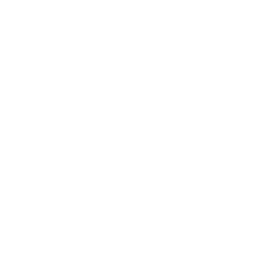
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Klasifikace molekulárních podtypů z genové exprese</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Biotechnologie / Genomická onkologie &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Manažerské shrnutí

Klasifikace vzorků nádorové biopsie do čtyř molekulárních podtypů (Luminal-A, Luminal-B, HER2-enriched, Basal-like) pomocí panelů biomarkerů genové exprese. Aplikace kanonické diskriminační analýzy k redukci vysokodimenzionálního prostoru exprese na interpretovatelné osy variability. Použití MANOVA k otestování, zda se průměrné expresní profily mezi podtypy významně liší. Křížová validace k odhadu spolehlivosti klasifikace pro podporu klinického rozhodování při volbě léčebné cesty.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.GENE_EXPR | Genová exprese nádoru se štítky podtypů | 100 |
| WORK.NEW_BIOPSIES | Neklasifikované vzorky biopsie | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generování syntetické datové sady genové exprese
   se čtyřmi molekulárními podtypy
   -------------------------------------------------------- */
data work.gene_expr;
    CALL streaminit(42);
    DÉLKA mol_subtype $12;
    POLE subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    OPAKUJ sample_id = 1 TO 100;
        tumor_id = cat('TUM-', ZAPSAT(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Simulované markery genové exprese (škála log2) */
        VYBRAT (mol_subtype);
            KDYŽ_V ('LUMINAL_A') OPAKUJ;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            KONEC;
            KDYŽ_V ('LUMINAL_B') OPAKUJ;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            KONEC;
            KDYŽ_V ('HER2_ENRICH') OPAKUJ;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            KONEC;
            KDYŽ_V ('BASAL_LIKE') OPAKUJ;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            KONEC;
            JINAK_V;
        KONEC;
        VÝSTUP;
    KONEC;
    ODSTRANIT sub_idx;
    ŠTÍTEK mol_subtype='Molekulární podtyp'
          tumor_id='ID nádoru'
          esr1_expr='Exprese ESR1 (log2)'
          pgr_expr='Exprese PGR (log2)'
          erbb2_expr='Exprese ERBB2 (log2)'
          ki67_expr='Exprese Ki-67 (log2)'
          egfr_expr='Exprese EGFR (log2)'
          cytokeratin5='Cytokeratin 5 (log2)'
          tp53_mut_load='Mutační zátěž TP53'
          prolif_score='Skóre proliferace';
SPUSTIT;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generování neklasifikovaných vzorků biopsie
   -------------------------------------------------------- */
data work.new_biopsies;
    CALL streaminit(55);
    OPAKUJ sample_id = 5001 TO 5100;
        tumor_id = cat('TUM-', ZAPSAT(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        VÝSTUP;
    KONEC;
    ŠTÍTEK mol_subtype='Molekulární podtyp'
          tumor_id='ID nádoru'
          esr1_expr='Exprese ESR1 (log2)'
          pgr_expr='Exprese PGR (log2)'
          erbb2_expr='Exprese ERBB2 (log2)'
          ki67_expr='Exprese Ki-67 (log2)'
          egfr_expr='Exprese EGFR (log2)'
          cytokeratin5='Cytokeratin 5 (log2)'
          tp53_mut_load='Mutační zátěž TP53'
          prolif_score='Skóre proliferace';
SPUSTIT;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                            Rozdělení molekulárních podtypů                                             

                                                   The FREQ Procedure

Molekulární podtyp      Frequency    Percent
---------------------------------------------
BASAL_LIKE                     24     24.00
HER2_ENRICH                    22     22.00
LUMINAL_A                      25     25.00
LUMINAL_B                      29     29.00
                                   Souhrn genové exprese podle molekulárního podtypu                                    

                                                  The MEANS Procedure

                                   Analysis Variable : esr1_expr Exprese ESR1 (log2)

        Molekulární podtyp            N Obs           Mean        Std Dev
        -----------------------------------------------------------------
        BASAL_LIKE                       24      4.5479167      1.2257100
        HER2_ENRICH                    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


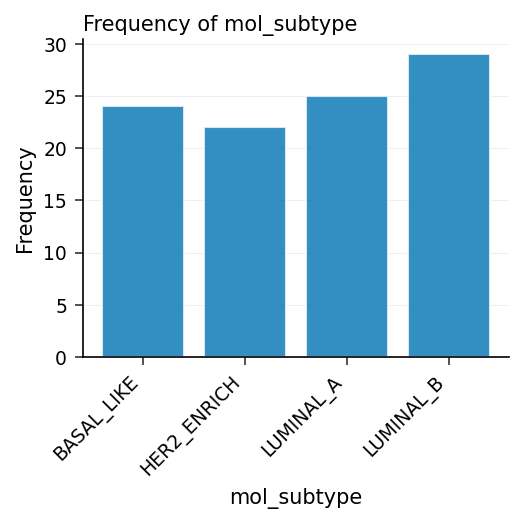

In [3]:
/* --------------------------------------------------------
   Základní rozdělení podtypů a profily exprese
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.gene_expr;
    TABLES mol_subtype / nocum;
    NÁZEV 'Rozdělení molekulárních podtypů';
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.gene_expr n mean std;
    TŘÍDA mol_subtype;
    PROMĚNNÁ esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    NÁZEV 'Souhrn genové exprese podle molekulárního podtypu';
SPUSTIT;

---

In [4]:
/* --------------------------------------------------------
   Kanonická diskriminační analýza s MANOVA
   CANONICAL extrahuje diskriminační osy pro vizualizaci.
   MANOVA testuje celkové oddělení průměrů mezi podtypy.
   -------------------------------------------------------- */
PROCEDURA DISCRIM data=work.gene_expr
        METHOD=NORMAL
        pool=TEST
        canonical
        MANOVA
        crossvalidate
        out=work.subtype_canonical
        OUTSTAT=work.subtype_stats;
    TŘÍDA mol_subtype;
    PROMĚNNÁ esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    NÁZEV 'Kanonická diskriminační analýza: molekulární podtypy nádoru';
    title2 'MANOVA test rozdílů průměrných expresních profilů';
SPUSTIT;

                                   Souhrn genové exprese podle molekulárního podtypu                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                   Souhrn genové exprese podle molekulárního podtypu                                    




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


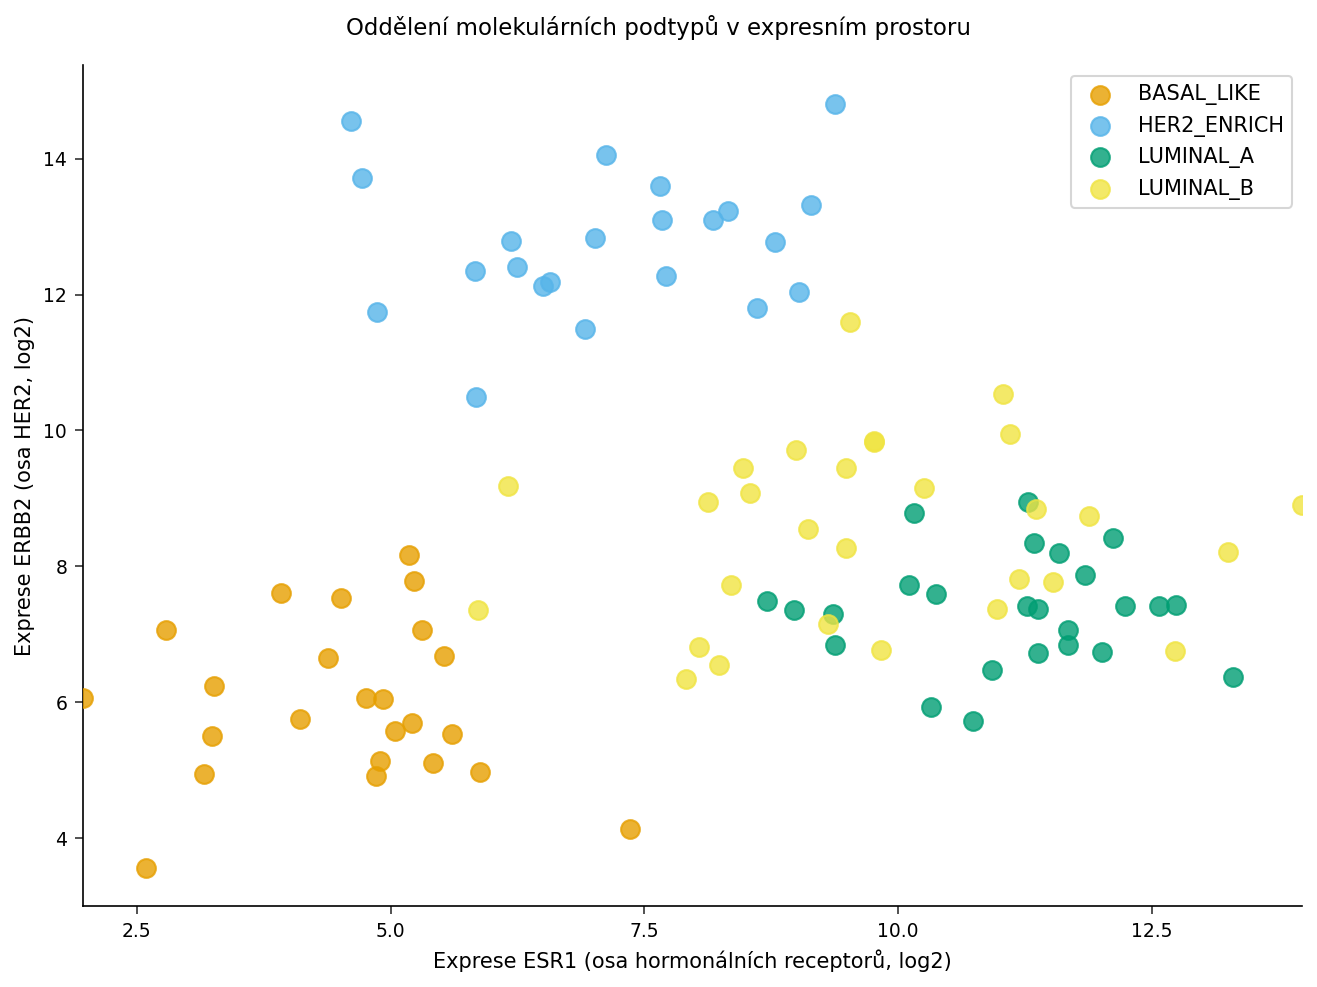

In [5]:
/* --------------------------------------------------------
   Oddělení podtypů v expresním prostoru
   ESR1 (osa hormonálních receptorů) vs ERBB2 (osa HER2),
   z výstupní datové sady OUT= diskriminace.
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.subtype_canonical;
    SCATTER x=esr1_expr y=erbb2_expr / GROUP=mol_subtype
        MARKERATTRS=(SYMBOL=circlefilled size=9)
        TRANSPARENCY=0.2;
    XAXIS ŠTÍTEK='Exprese ESR1 (osa hormonálních receptorů, log2)';
    YAXIS ŠTÍTEK='Exprese ERBB2 (osa HER2, log2)';
    NÁZEV 'Oddělení molekulárních podtypů v expresním prostoru';
SPUSTIT;


In [6]:
/* --------------------------------------------------------
   Klasifikace netypovaných vzorků biopsie
   -------------------------------------------------------- */
PROCEDURA DISCRIM data=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        METHOD=NORMAL
        pool=TEST
        canonical;
    TŘÍDA mol_subtype;
    PROMĚNNÁ esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    PRIORS equal;
    NÁZEV 'Klasifikace molekulárních podtypů nových biopsií';
SPUSTIT;

                                   Souhrn genové exprese podle molekulárního podtypu                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                               Predikované rozdělení molekulárních podtypů: nové biopsie                                

                                                   The FREQ Procedure

Predikovaný molekulární podtyp       Frequency    Percent
----------------------------------------------------------
BASAL_LIKE                                   7      7.00
HER2_ENRICH                                 47     47.00
LUMINAL_A                                   10     10.00
LUMINAL_B                                   36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


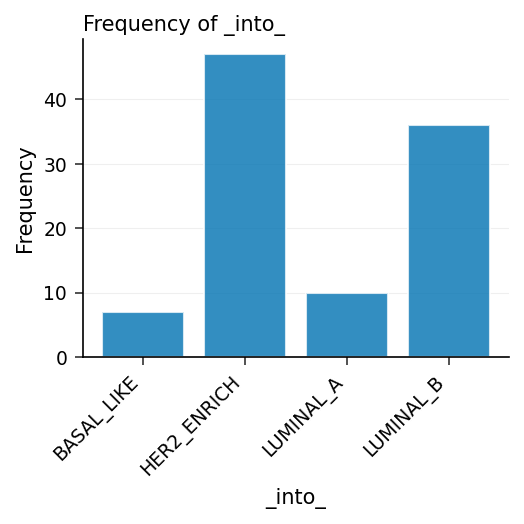

In [7]:
/* --------------------------------------------------------
   Rozdělení klasifikace pro nové biopsie
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.classified_biopsies;
    TABLES _into_ / nocum;
    ŠTÍTEK _into_='Predikovaný molekulární podtyp';
    NÁZEV 'Predikované rozdělení molekulárních podtypů: nové biopsie';
SPUSTIT;

---

### Interpretace

Test MANOVA potvrzuje vysoce významný rozdíl v průměrných profilech genové exprese napříč čtyřmi molekulárními podtypy: Wilksova lambda = 0.0037 s p < 0.0001, takže podtypy zaujímají zřetelně odlišné oblasti osmimarkerového prostoru exprese. Toto oddělení je viditelné v bodovém grafu prostoru exprese, kde luminální nádory leží vysoko na ose ESR1 (hormonální receptor), zatímco nádory HER2-enriched se tlačí na vrchol osy ERBB2 a nádory Basal-like padají do levého dolního rohu obou os. Resubstituční klasifikace 100 označených nádorů je bezchybná (0% zdánlivá chyba) a křížová validace typu leave-one-out stanovuje chybovost na pouhá 4 % — poctivá 96% přesnost při křížové validaci, přičemž každý podtyp je v křížově validované matici záměn správně obnoven. Aplikace natrénovaného klasifikátoru na 100 neoznačených biopsií přiřadí 47 k HER2-enriched, 36 k Luminal-B, 10 k Luminal-A a 7 k Basal-like; příklon k HER2-enriched odráží zvýšené hodnoty ERBB2 a proliferace v panelu biopsií. Tyto určené podtypy řídí volbu léčebné cesty: endokrinní terapie u luminálních nádorů, cílené anti-HER2 přípravky pro skupinu HER2-enriched a chemoterapeutické režimy u nádorů Basal-like.


---

In [8]:
/* --------------------------------------------------------
   Export klasifikovaných biopsií pro plánování léčby
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.classified_biopsies
    OUTFILE='classified_biopsy_subtypes.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.subtype_canonical
    OUTFILE='canonical_subtype_scores.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Využívá <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>